[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almahova/iemocap-proj/blob/data-modelling/iemocap_modelling.ipynb)

# IEMOCAP Emotion Recognition Modelling Pipeline
## late fusion

This notebook implements a **late fusion model** for 3-class Speech Emotion Recognition (SER) on the IEMOCAP corpus.

| Component | Choice |
|-----------|--------|
| Model | `roberta-base` and `wav2vec2` fine-tuned for sequence classification |
| Split | Stratified 80 % train · 10 % val · 10 % test |
| Loss | Weighted Cross-Entropy (compensates ~55 % Negative imbalance) |
| Primary metric | **Macro F1-Score** |
| Classes | `Negative` (0) · `Positive` (1) · `Neutral` (2) |

## Approach

This notebook implements **late fusion** as a weighted sum of logits from two
independently fine-tuned models:

- **Text model** (`text_best_model_weights.pt`) `roberta-base` fine-tuned for
  3-class emotion classification.
- **Audio model** (`best_model.pt`) `facebook/wav2vec2-base` fine-tuned for
  3-class emotion classification, trained with **LOSO-CV** (Sessions 1-4 train,
  Session 5 held out as test).

To get a clean **1-to-1 matched test set** for both modalities, this notebook
evaluates on **Session 5 (`Ses05`)** the same held-out split used to train/evaluate
the audio model.

Final logits are combined as:

```
Final Logits = 0.65 * text_logits + 0.35 * audio_logits
```

> **Caveat:** the text model's *original* test set (in `text_classification.ipynb`)
> was a random 80/10/10 stratified split (seed=42) over the **full** dataset not
> a session-based split. Some `Ses05` rows may therefore have been part of the text
> model's training data, so its score in *this* evaluation could be optimistically
> biased relative to its originally-reported numbers (Acc 0.7052 / Macro F1 0.6648).
> The audio model's `Ses05` score, by contrast, is a clean held-out evaluation by
> design. This doesn't block the late-fusion exercise but should be kept in mind
> when interpreting the text-only results below.

In [16]:
import os
import io
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torchaudio.transforms as T

from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from datasets import load_dataset
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.11.0+cu128


In [17]:
# ── All hyperparameters in one place change here, nowhere else ──────────────
CONFIG = {
    "text_model_name":  "roberta-base",
    "audio_model_name": "facebook/wav2vec2-base",
    "max_length":       128,     # text tokenizer max length
    "max_duration":     4.0,     # audio seconds must match best_model.pt training
    "target_sr":        16_000,  # Hz required by Wav2Vec2
    "batch_size":       16,
    "num_labels":       3,
    "test_session":     5,       # LOSO: Ses05 held out as test set
    "alpha_text":       0.65,
    "alpha_audio":      0.35,
    "random_seed":      42,
}

LABEL2ID = {"Negative": 0, "Positive": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
CLASS_NAMES = ["Negative", "Positive", "Neutral"]

EMOTION_GROUP_MAP = {
    "happy":      "Positive",
    "excited":    "Positive",
    "angry":      "Negative",
    "frustrated": "Negative",
    "fear":       "Negative",
    "sad":        "Negative",
    "disgust":    "Negative",
    "other":      "Neutral",
    "neutral":    "Neutral",
    "surprise":   "Neutral",
}

# ── Checkpoint locations ───────────────────────────────────────────────────
from google.colab import drive
import sys

print("google.colab" in sys.modules)

drive.mount('/content/drive')
CHECKPOINT_DIR = "/content/drive/MyDrive" # Note: this paht is Alma's dirve - change it id needed

TEXT_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "text_best_model_weights.pt")
AUDIO_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "audio_best_model.pt")

torch.manual_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Load Dataset & Build LOSO `Ses05` Test Set

In [18]:
ds = load_dataset("AbstractTTS/IEMOCAP")
df = ds["train"].to_pandas()

df["emotion_group"] = df["major_emotion"].map(EMOTION_GROUP_MAP)
# df = df.dropna(subset=["emotion_group", "transcription", "audio"]).reset_index(drop=True)
df["label"] = df["emotion_group"].map(LABEL2ID)

# Extract integer session number (1-5) for LOSO split
df["session_num"] = df["file"].str.extract(r"Ses(\d{2})").astype(int)

test_df = df[df["session_num"] == CONFIG["test_session"]].reset_index(drop=True)

print(f"Ses{CONFIG['test_session']:02d} test set: {len(test_df)} samples")
print(test_df["emotion_group"].value_counts().to_string())

Ses05 test set: 2170 samples
emotion_group
Negative    1149
Positive     613
Neutral      408


---
## 2. Datasets & DataLoaders

Both modalities are built from the **same `test_df`** with `shuffle=False`, so row `i` of the text loader corresponds to row `i` of the audio loader this guarantees 1-to-1 alignment for late fusion.

In [19]:
class IEMOCAPTextDataset(Dataset):
    """PyTorch Dataset that tokenises transcription text for RoBERTa."""

    def __init__(self, texts: list, labels: list, tokenizer, max_length: int):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


class IEMOCAPDataset(Dataset):
    """PyTorch Dataset for IEMOCAP audio emotion classification (Wav2Vec2)."""

    def __init__(self, df, processor, max_duration, target_sr):
        self.df         = df.reset_index(drop=True)
        self.processor  = processor
        self.max_length = int(max_duration * target_sr)
        self.target_sr  = target_sr

    def __len__(self):
        return len(self.df)

    def _load_audio(self, audio_data):
        raw_bytes = audio_data.get("bytes")
        waveform, sr = sf.read(io.BytesIO(raw_bytes), dtype="float32")
        if waveform.ndim > 1:
            waveform = waveform.mean(axis=-1)
        return waveform, sr

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform, sr = self._load_audio(row["audio"])

        if sr != self.target_sr:
            waveform_t = torch.from_numpy(waveform).unsqueeze(0)
            resampler  = T.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform   = resampler(waveform_t).squeeze(0).numpy()

        encoded = self.processor(
            waveform,
            sampling_rate=self.target_sr,
            return_tensors="pt",
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
        )

        return {
            "input_values": encoded["input_values"].squeeze(0),
            "attention_mask": encoded.get(
                "attention_mask", torch.ones(self.max_length)
            ).squeeze(0),
            "labels": torch.tensor(row["label"], dtype=torch.long),
        }


text_tokenizer  = RobertaTokenizer.from_pretrained(CONFIG["text_model_name"])
audio_processor = Wav2Vec2Processor.from_pretrained(CONFIG["audio_model_name"])

text_test_ds = IEMOCAPTextDataset(
    texts=test_df["transcription"].tolist(),
    labels=test_df["label"].tolist(),
    tokenizer=text_tokenizer,
    max_length=CONFIG["max_length"],
)
audio_test_ds = IEMOCAPDataset(
    test_df, audio_processor,
    max_duration=CONFIG["max_duration"], target_sr=CONFIG["target_sr"],
)

text_loader  = DataLoader(text_test_ds,  batch_size=CONFIG["batch_size"], shuffle=False)
audio_loader = DataLoader(audio_test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Batches text: {len(text_loader)} | audio: {len(audio_loader)}")

Batches text: 136 | audio: 136


---
## 3. Load Pretrained Models

In [20]:
text_model = RobertaForSequenceClassification.from_pretrained(
    CONFIG["text_model_name"],
    num_labels=CONFIG["num_labels"],
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
text_model.load_state_dict(torch.load(TEXT_CKPT_PATH, map_location=device))
text_model.to(device).eval()

audio_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    CONFIG["audio_model_name"],
    num_labels=CONFIG["num_labels"],
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
audio_model.load_state_dict(torch.load(AUDIO_CKPT_PATH, map_location=device))
audio_model.freeze_feature_encoder()
audio_model.to(device).eval()

print("Both models loaded.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Both models loaded.


---
## 4. Inference Extract Logits

In [21]:
@torch.no_grad()
def extract_text_logits(model, loader, device):
    all_logits, all_labels = [], []
    for batch in tqdm(loader, desc="text inference"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


@torch.no_grad()
def extract_audio_logits(model, loader, device):
    all_logits, all_labels = [], []
    for batch in tqdm(loader, desc="audio inference"):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        logits = model(input_values=input_values, attention_mask=attention_mask).logits
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


text_logits,  text_labels  = extract_text_logits(text_model, text_loader, device)
audio_logits, audio_labels = extract_audio_logits(audio_model, audio_loader, device)

# Both loaders are built from the same test_df with shuffle=False, so row order
# must be identical verify before fusing.
assert torch.equal(text_labels, audio_labels), "Row order mismatch between text and audio loaders!"
true_labels = text_labels.numpy()

print(f"text_logits : {tuple(text_logits.shape)}")
print(f"audio_logits: {tuple(audio_logits.shape)}")

audio inference: 100%|██████████| 136/136 [00:42<00:00,  3.22it/s]

text_logits : (2170, 3)
audio_logits: (2170, 3)


---
## 5. Late Fusion Weighted Logit Sum

In [22]:
fused_logits = (CONFIG["alpha_text"] * text_logits) + (CONFIG["alpha_audio"] * audio_logits)
fused_probs  = torch.softmax(fused_logits, dim=-1).numpy()
fused_preds  = fused_logits.argmax(dim=-1).numpy()

# Single-modality predictions for comparison
text_preds  = text_logits.argmax(dim=-1).numpy()
audio_preds = audio_logits.argmax(dim=-1).numpy()

---
## 6. Evaluation

In [23]:
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== {name} ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    return acc, macro_f1, weighted_f1


report("Text-only (Ses05)",  true_labels, text_preds)
report("Audio-only (Ses05)", true_labels, audio_preds)
fused_acc, fused_macro_f1, fused_weighted_f1 = report(
    f"Late Fusion (alpha_text={CONFIG['alpha_text']}, alpha_audio={CONFIG['alpha_audio']})",
    true_labels, fused_preds,
)


=== Text-only (Ses05) ===
Accuracy:    0.8272
Macro F1:    0.8089
Weighted F1: 0.8335
              precision    recall  f1-score   support

    Negative       0.93      0.81      0.87      1149
    Positive       0.87      0.84      0.86       613
     Neutral       0.60      0.84      0.70       408

    accuracy                           0.83      2170
   macro avg       0.80      0.83      0.81      2170
weighted avg       0.85      0.83      0.83      2170


=== Audio-only (Ses05) ===
Accuracy:    0.6779
Macro F1:    0.6324
Weighted F1: 0.6799
              precision    recall  f1-score   support

    Negative       0.76      0.78      0.77      1149
    Positive       0.72      0.56      0.63       613
     Neutral       0.45      0.55      0.49       408

    accuracy                           0.68      2170
   macro avg       0.64      0.63      0.63      2170
weighted avg       0.69      0.68      0.68      2170


=== Late Fusion (alpha_text=0.65, alpha_audio=0.35) ===
Accura

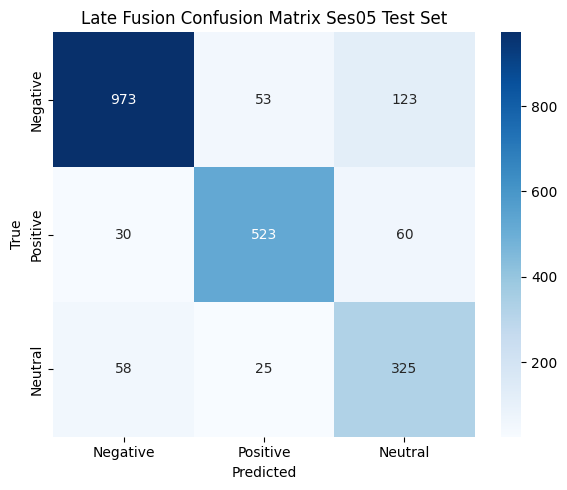

In [24]:
cm = confusion_matrix(true_labels, fused_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Late Fusion Confusion Matrix Ses{CONFIG['test_session']:02d} Test Set")
plt.tight_layout()
plt.show()

---
## 7. Save Predictions

In [25]:
results_df = pd.DataFrame({
    "file": test_df["file"],
    "true_label": true_labels,
    "true_emotion": [ID2LABEL[l] for l in true_labels],
    "text_pred": text_preds,
    "audio_pred": audio_preds,
    "fused_pred": fused_preds,
    "fused_emotion": [ID2LABEL[p] for p in fused_preds],
    "prob_negative": fused_probs[:, 0],
    "prob_positive": fused_probs[:, 1],
    "prob_neutral":  fused_probs[:, 2],
})
results_df.to_csv("late_fusion_predictions.csv", index=False)
print("Saved late_fusion_predictions.csv")
results_df.head()

Saved late_fusion_predictions.csv


,file,true_label,true_emotion,text_pred,audio_pred,fused_pred,fused_emotion,prob_negative,prob_positive,prob_neutral
0,Ses05F_impro01_F000.wav,2,Neutral,2,0,2,Neutral,0.283038,0.017552,0.699410
1,Ses05F_impro01_F001.wav,0,Negative,0,2,0,Negative,0.915377,0.008660,0.075963
2,Ses05F_impro01_F002.wav,0,Negative,0,0,0,Negative,0.964749,0.010295,0.024956
3,Ses05F_impro01_F003.wav,0,Negative,0,2,0,Negative,0.819265,0.011704,0.169031
4,Ses05F_impro01_F004.wav,0,Negative,0,2,0,Negative,0.610820,0.016586,0.372593
